## Mutivariate Analysis

In [10]:
# Section 1 — Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("default")


# Section 2 — Load Dataset
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)



# Numerical Features

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


# Categorical Features

categorical_features = df.select_dtypes(
    include="object"
).columns.tolist()


print("Numerical Features")
print(numerical_features)

print()

print("Categorical Features")
print(categorical_features)


categorical_features.remove("customerID")


summary = pd.DataFrame({

    "Data Type": df.dtypes,

    "Missing Values": df.isnull().sum(),

    "Unique Values": df.nunique()

})

summary

Numerical Features
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


,Data Type,Missing Values,Unique Values
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,int64,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3


## Part A — Numerical vs Numerical Relationships

This section explores the relationships among numerical features in the dataset.

Unlike bivariate analysis, which focused on the relationship between a single feature and the target variable, this analysis examines how numerical features interact with one another.

Understanding these relationships helps identify:

- Strong correlations between variables.
- Redundant features that may provide similar information.
- Potential multicollinearity issues.
- Linear or non-linear trends.
- Clusters and outliers.

The primary numerical features considered in this analysis are:

- `tenure`
- `MonthlyCharges`
- `TotalCharges`

The insights gained from this analysis will support feature selection and engineering in later stages of the project.

### Helper Function 1: Correlation Matrix

This helper function computes the Pearson correlation matrix for the selected numerical features.

The correlation matrix quantifies the strength and direction of the linear relationship between every pair of numerical variables.

Correlation values range from **-1** to **1**:

- **1** indicates a perfect positive relationship.
- **-1** indicates a perfect negative relationship.
- **0** indicates no linear relationship.

This summary provides the foundation for identifying related features before visualizing them.

In [11]:
# Helper Function - 1

def display_correlation_matrix(df, columns):
    """
    Display the Pearson correlation matrix for
    selected numerical features.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    columns : list
        List of numerical feature names.
    """

    correlation_matrix = (
        df[columns]
        .corr(method="pearson")
        .round(2)
    )

    display(correlation_matrix)

In [12]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

display_correlation_matrix(df, numerical_columns)

,tenure,MonthlyCharges,TotalCharges
tenure,1.00,0.25,0.83
MonthlyCharges,0.25,1.00,0.65
TotalCharges,0.83,0.65,1.00


### Helper Function 2: Correlation Heatmap

This helper function visualizes the correlation matrix using a heatmap.

The heatmap provides an intuitive representation of the strength and direction of relationships among numerical features through color intensity.

It helps quickly identify:

- Strong positive correlations.
- Strong negative correlations.
- Weak or no relationships.
- Potential multicollinearity between features.

In [13]:
# Helper Function - 2

def plot_correlation_heatmap(df, columns):
    """
    Plot a correlation heatmap for selected
    numerical features.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    columns : list
        List of numerical feature names.
    """

    correlation_matrix = (
        df[columns]
        .corr(method="pearson")
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar=True
    )

    plt.title(
        "Correlation Heatmap",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()

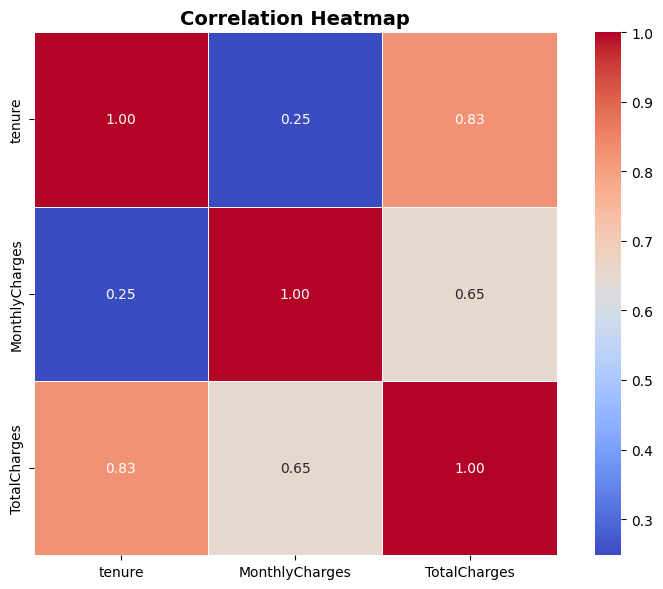

In [14]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

plot_correlation_heatmap(df, numerical_columns)

### Helper Function 3: Pair Plot

This helper function creates a pair plot for the selected numerical features.

A pair plot displays pairwise scatter plots between numerical variables along with the distribution of each feature on the diagonal.

It helps identify:

- Linear and non-linear relationships.
- Clusters of observations.
- Potential outliers.
- Feature distributions.
- Pairwise trends among numerical variables.

In [ ]:
# Helper Function - 3

def plot_pairplot(df, columns):
    """
    Create a pair plot for selected numerical features.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    columns : list
        List of numerical feature names.
    """

    sns.pairplot(
        data=df[columns],
        diag_kind="hist",
        corner=True
    )

    plt.suptitle(
        "Pair Plot of Numerical Features",
        fontsize=16,
        fontweight="bold",
        y=1.02
    )

    plt.show()

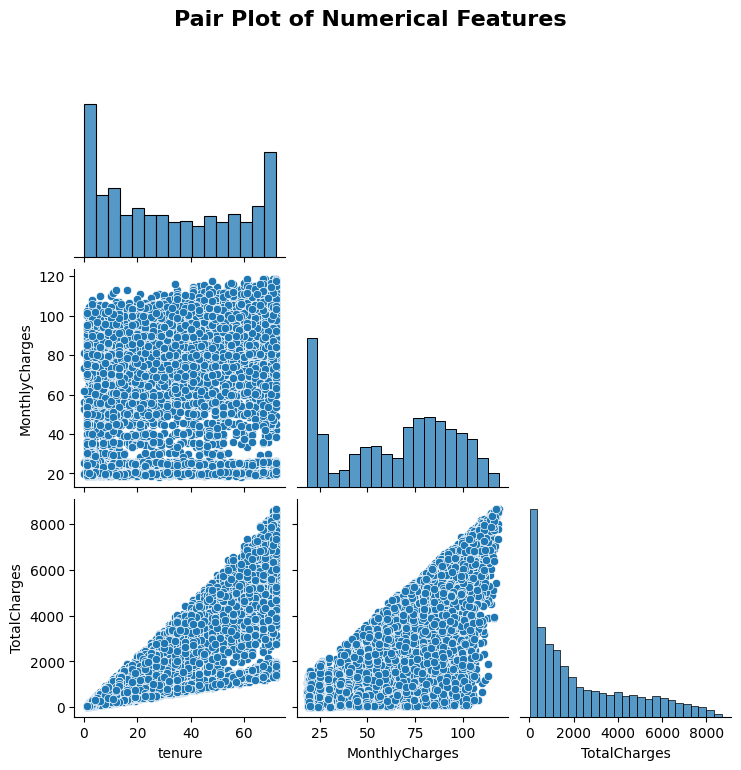

In [16]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

plot_pairplot(df, numerical_columns)

### Helper Function 4: Scatter Plot

This helper function visualizes the relationship between two numerical features using a scatter plot.

Each point represents an individual customer, allowing us to examine how one numerical feature varies with another.

The scatter plot helps identify:

- Positive or negative relationships.
- Linear and non-linear trends.
- Clusters of observations.
- Potential outliers.
- Overall patterns between two numerical variables.

In [19]:
# Helper Function - 4

def plot_scatter_relationship(df, x_column, y_column):
    """
    Plot the relationship between two numerical features
    using a scatter plot.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    x_column : str
        Feature for the x-axis.

    y_column : str
        Feature for the y-axis.
    """

    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=df,
        x=x_column,
        y=y_column,
        alpha=0.7
    )

    plt.title(
        f"{x_column} vs {y_column}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(x_column)
    plt.ylabel(y_column)

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

In [ ]:
plot_scatter_relationship(df, "tenure", "MonthlyCharges")

plot_scatter_relationship(df, "tenure", "TotalCharges")

plot_scatter_relationship(df, "MonthlyCharges", "TotalCharges")